# 04 Statistical Analysis and KPIs

In this notebook, I'll calculate some specific numbers like Year-over-Year (YoY) growth and identify which districts are not doing well compared to the rest of India.

### Imports and Visual Style Setup

Load analysis libraries and define a shared plotting style (colors, grid, fonts, and footer).

This keeps all statistical charts visually consistent across the notebook.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MAIN_COLOR = "#1B365D"
MID_COLOR = "#2F5D8A"
FILL_COLOR = "#7EA6C2"
BG_COLOR = "#F9FAFB"
GRID_COLOR = "#C7D2E0"
TEXT_COLOR = "#4B5563"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def style_ax(ax, vertical_grid=True):
    ax.set_facecolor(BG_COLOR)
    if vertical_grid:
        ax.grid(axis="y", linestyle="--", linewidth=1, alpha=0.5, color=GRID_COLOR)
    else:
        ax.grid(axis="x", linestyle="--", linewidth=1, alpha=0.5, color=GRID_COLOR)


def add_footer(ax):
    ax.text(
        0.0,
        -0.18,
        "Source: India APY dataset | Reporting window: 2011-2019",
        transform=ax.transAxes,
        fontsize=10,
        color=TEXT_COLOR,
        ha="left"
    )

### Load Cleaned Dataset

Read the cleaned dataset from `../data/processed/cleaned_data.csv`.

All KPI and statistical calculations below are based on this processed table.

In [57]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

### Correlation Table for Core Numeric Features

Compute pairwise correlation among `area`, `production`, and `yield`.

This gives a quick numeric view of linear relationships before plotting the heatmap.

In [58]:
corr = df[["area", "production", "yield"]].corr()
corr

,area,production,yield
area,1.000000,0.291802,-0.010362
production,0.291802,1.000000,0.216648
yield,-0.010362,0.216648,1.000000


### Correlation Matrix Heatmap

Visualize the correlation table with a color scale and in-cell values.

Darker cells indicate stronger positive correlation; values close to zero indicate weak linear relationship.

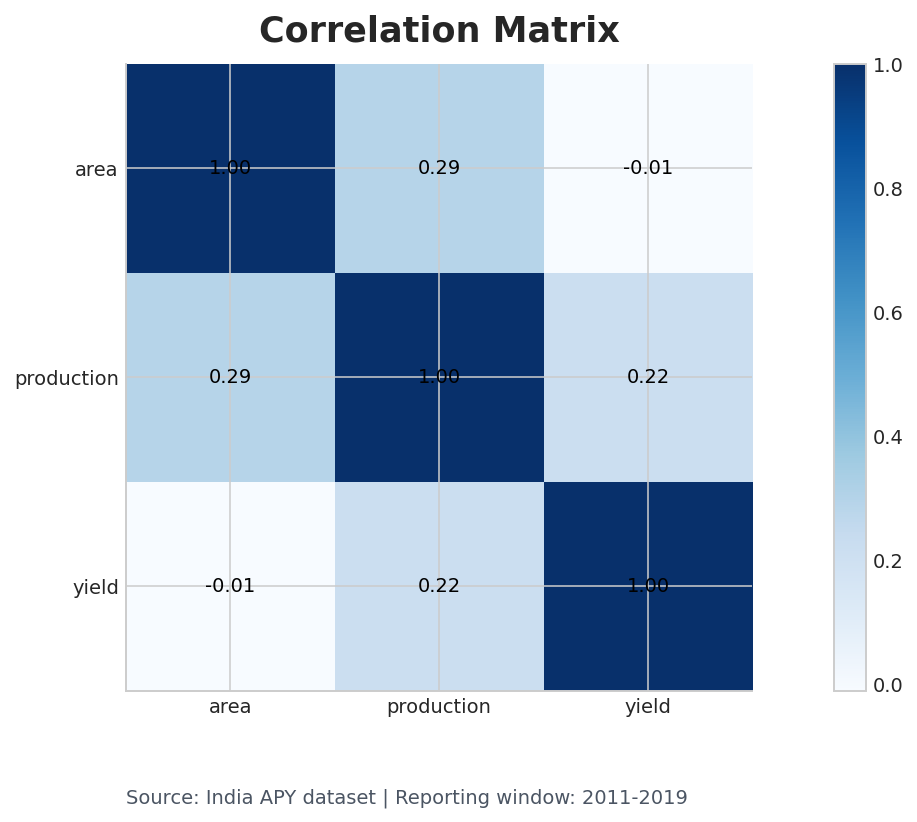

In [59]:
fig, ax = plt.subplots()
heatmap = ax.imshow(corr, cmap="Blues")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Matrix", pad=12)
plt.colorbar(heatmap)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_facecolor(BG_COLOR)
add_footer(ax)
plt.tight_layout()
plt.show()

### Yield Distribution Histogram

Plot the distribution of `yield` values to inspect spread and concentration.

This helps identify skewness and possible extreme values before interpreting averages.

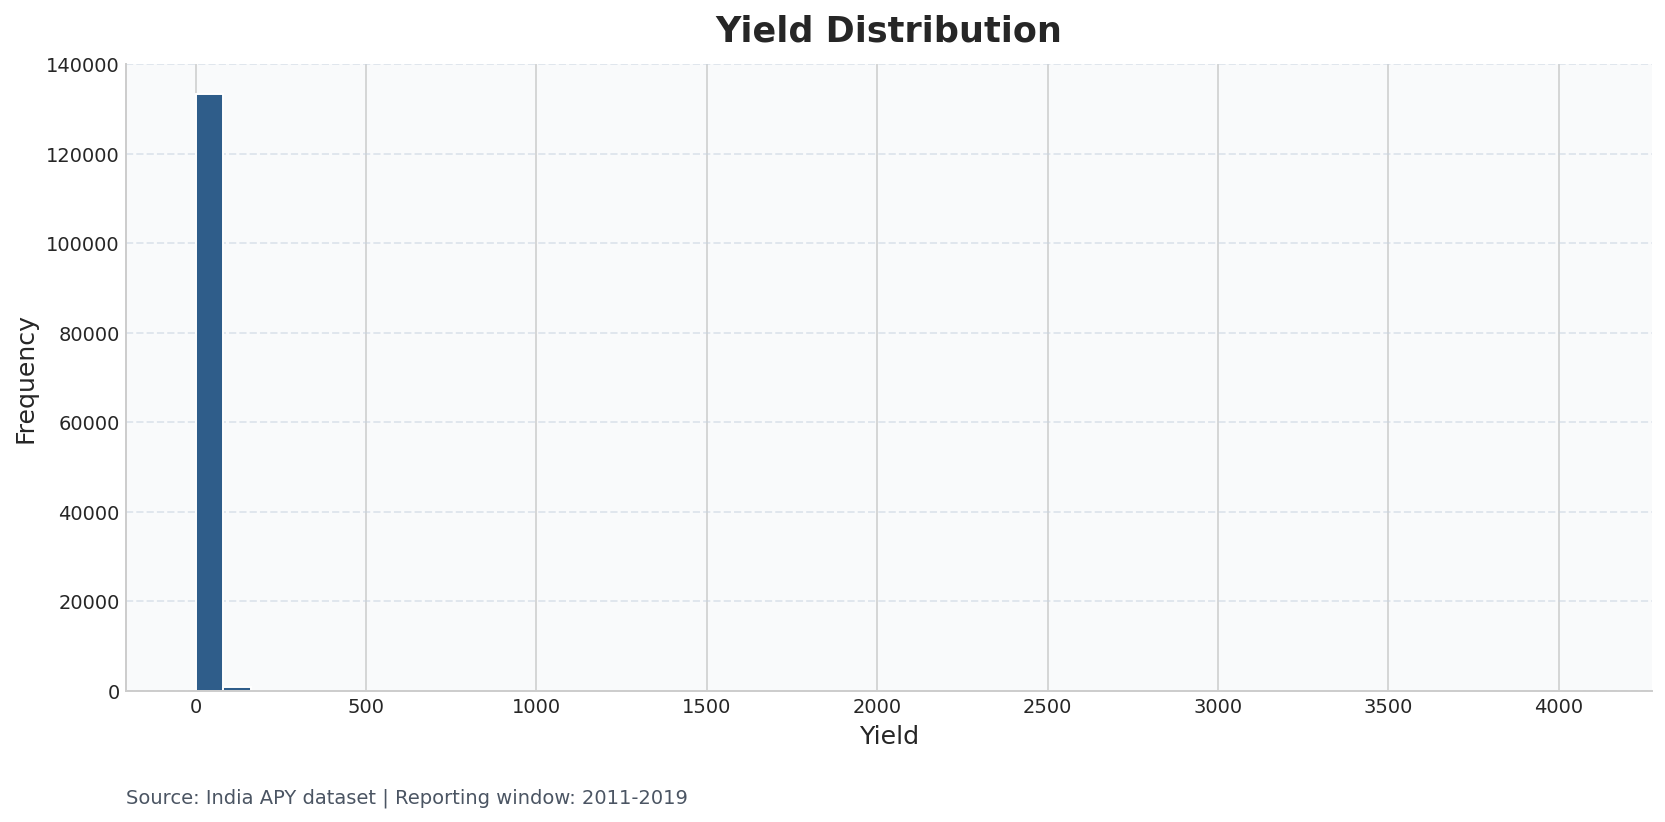

In [60]:
fig, ax = plt.subplots()
ax.hist(df["yield"], bins=50, color=MID_COLOR, edgecolor="white")
ax.set_title("Yield Distribution", pad=12)
ax.set_xlabel("Yield")
ax.set_ylabel("Frequency")

style_ax(ax, vertical_grid=True)
add_footer(ax)
plt.tight_layout()
plt.show()

### Summary Statistics Snapshot

Display descriptive statistics for `area` and `yield` (count, mean, quartiles, and max).

This gives a fast numeric baseline for scale and variability.

In [36]:
df[["area", "yield"]].describe()

,area,yield
count,1.343310e+05,134331.000000
mean,1.081325e+04,5.097251
std,3.732222e+04,18.851519
min,8.000000e-03,0.000000
25%,6.000000e+01,0.655400
50%,4.230000e+02,1.163907
75%,3.276000e+03,2.892857
max,1.133397e+06,4070.000000


### Area vs Yield Scatter Plot

Plot a random sample of points (`n = 10,000`) to visualize the relationship between cultivated area and yield.

Sampling keeps the chart readable while preserving overall pattern.

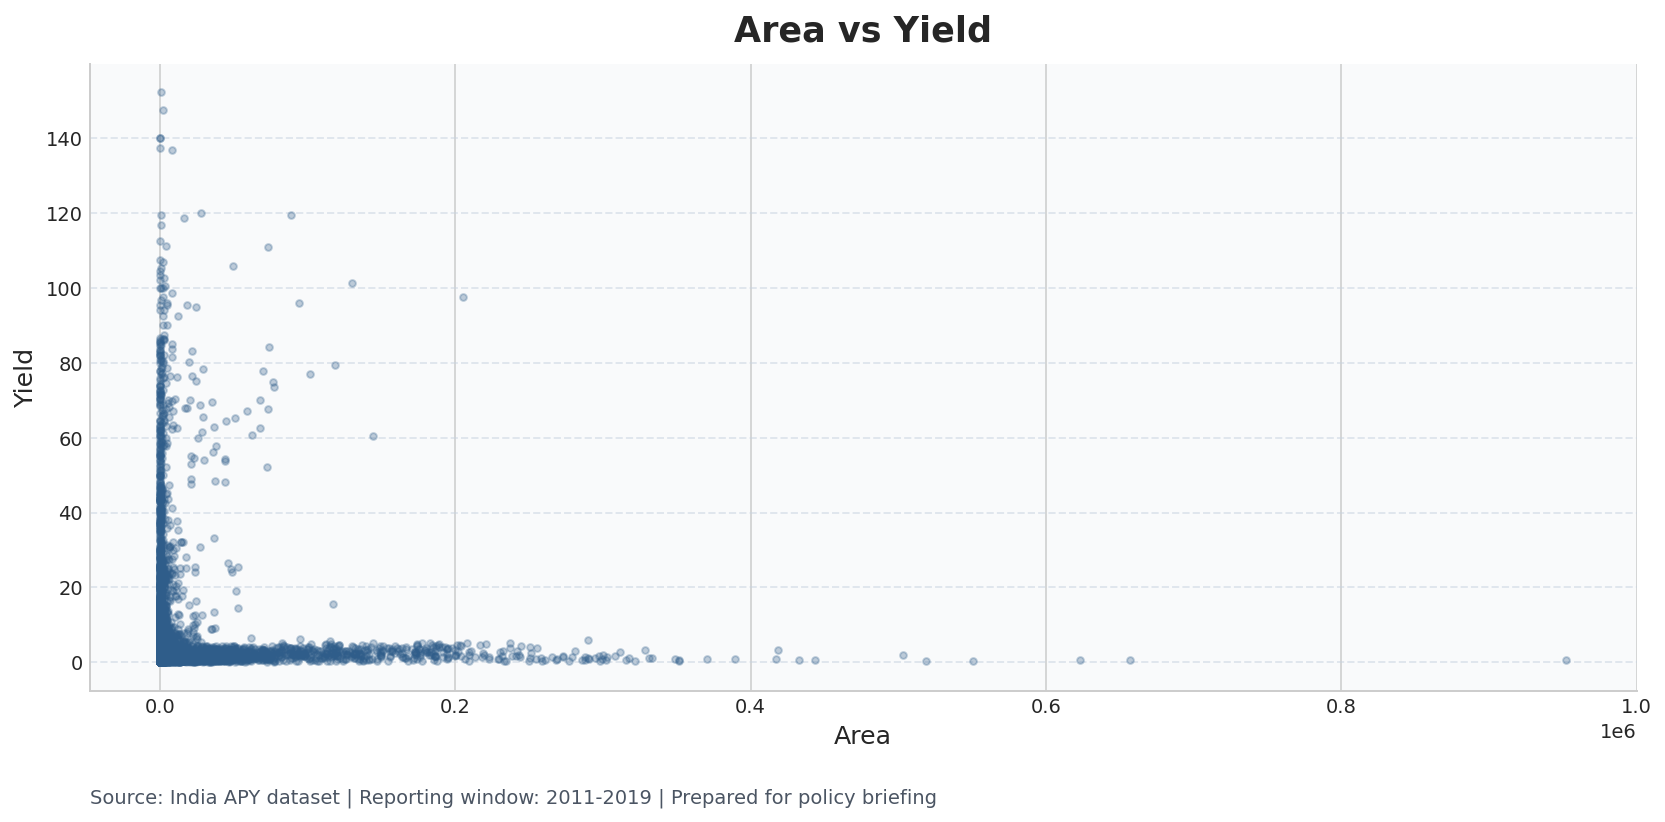

In [51]:
sample_df = df.sample(10000, random_state=42)

fig, ax = plt.subplots()
ax.scatter(sample_df["area"], sample_df["yield"], alpha=0.3, s=12, color=MID_COLOR)
ax.set_title("Area vs Yield", pad=12)
ax.set_xlabel("Area")
ax.set_ylabel("Yield")

style_ax(ax, vertical_grid=True)
add_footer(ax)
plt.tight_layout()
plt.show()

### Yearly Production and YoY Growth Series

Aggregate total production by year and compute year-over-year growth percentage.

The resulting `growth` series is reused for both tabular display and line visualization.

In [52]:
yearly_prod = df.groupby("year")["production"].sum()
growth = yearly_prod.pct_change() * 100

growth

year
2011          NaN
2013     5.015129
2014    -1.649648
2015    -6.782521
2016     8.034956
2017    10.739585
2018     0.591215
2019     1.932536
Name: production, dtype: float64

### YoY Growth Trend Chart

Plot the `growth` series as a line chart with a zero reference line.

This makes positive and negative production growth periods easy to compare across years.

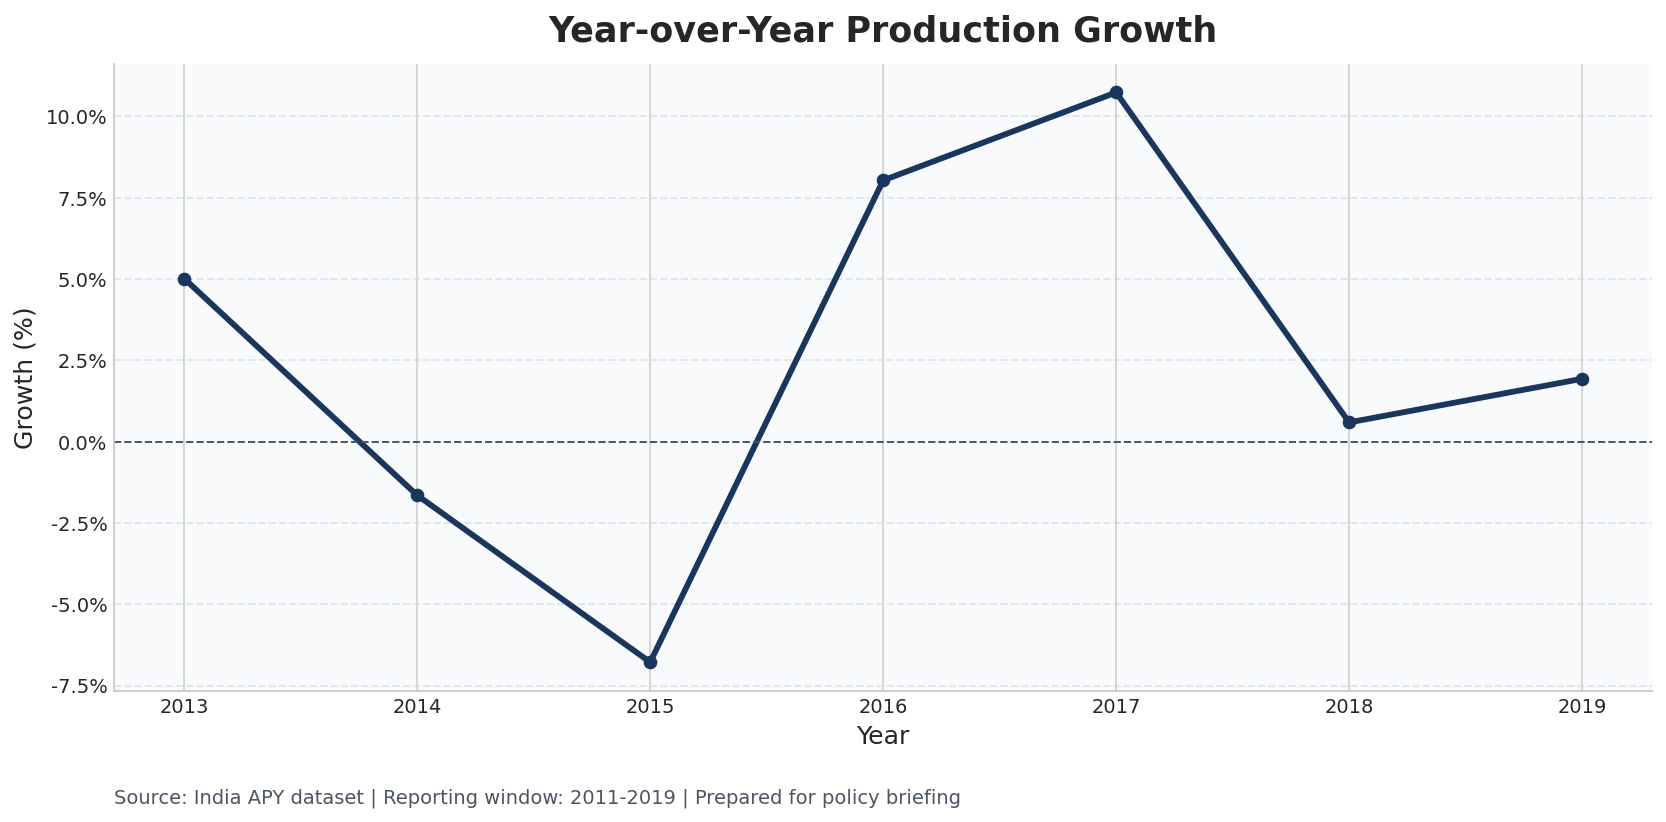

In [53]:
fig, ax = plt.subplots()
ax.plot(growth.index, growth.values, color=MAIN_COLOR, marker="o", linewidth=3)
ax.axhline(0, color=TEXT_COLOR, linestyle="--", linewidth=1)
ax.set_title("Year-over-Year Production Growth", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Growth (%)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.1f}%"))

style_ax(ax, vertical_grid=True)
add_footer(ax)
plt.tight_layout()
plt.show()

### Crop-Level Yield Volatility Metric

Compute standard deviation of yield for each crop and sort descending.

Higher values indicate crops with larger year-to-year or region-level yield variability.

In [54]:
yield_volatility = df.groupby("crop")["yield"].std().sort_values(ascending=False)

yield_volatility.head(10)

crop
Onion        71.691918
Sannhamp     36.257964
Sugarcane    29.232381
Tobacco      26.098000
Banana       24.272756
Tapioca      13.433443
Potato        9.445010
Jute          9.132154
Ginger        7.595960
Bajra         6.669166
Name: yield, dtype: float64

### Top 10 Volatile Crops (Chart)

Select the top 10 crops by volatility and visualize them in a horizontal bar chart.

This highlights crops that may require closer risk monitoring.

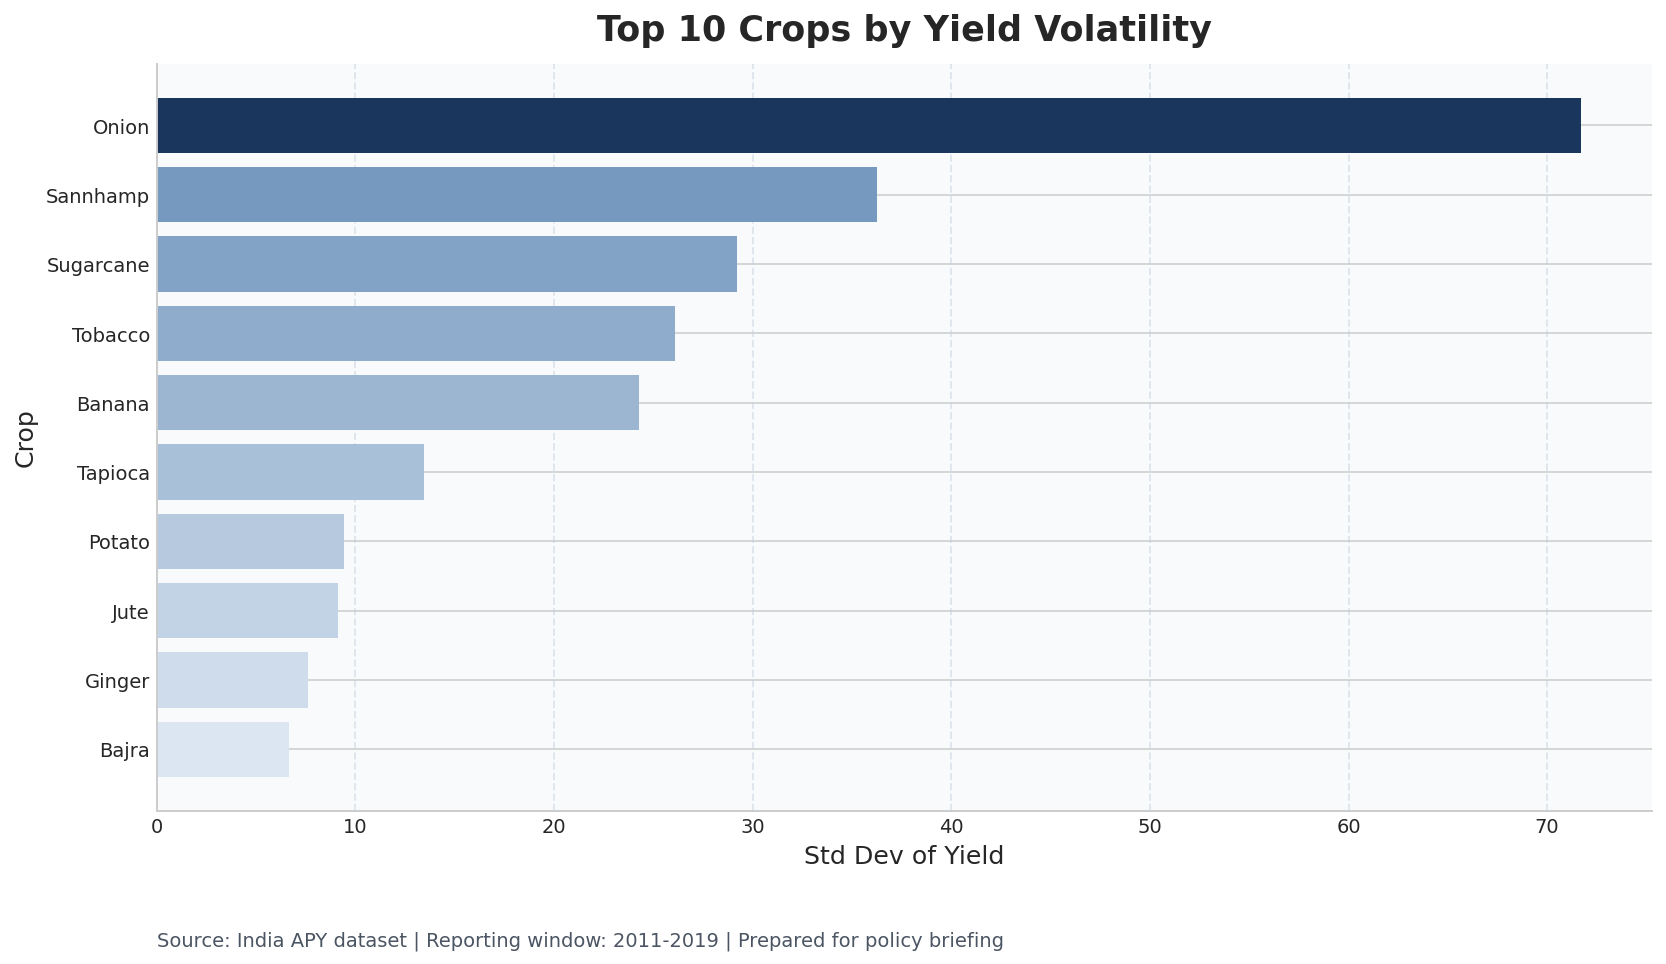

In [55]:
top_volatility = yield_volatility.head(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ["#DCE6F2", "#CFDCEC", "#C3D3E6", "#B6C9DF", "#A9C0D9", "#9CB6D2", "#8FACCC", "#82A3C6", "#7599BF", MAIN_COLOR]
ax.barh(top_volatility.index, top_volatility.values, color=bar_colors)
ax.set_title("Top 10 Crops by Yield Volatility", pad=12)
ax.set_xlabel("Std Dev of Yield")
ax.set_ylabel("Crop")

style_ax(ax, vertical_grid=False)
add_footer(ax)
plt.tight_layout()
plt.show()

### Top Crops by Average Yield

Compute mean yield by crop and preview the top performers.

This complements the volatility view by showing which crops are strong on average.

In [42]:
top_yield = df.groupby("crop")["yield"].mean().sort_values(ascending=False)

top_yield.head(10)

crop
Sugarcane       59.959615
Banana          36.449604
Tapioca         20.202685
Onion           15.619986
Potato          14.004605
Sweet potato    10.791481
Jute            10.600493
Ginger           9.055618
Garlic           5.504150
Mesta            5.425490
Name: yield, dtype: float64

### Area-Heavy, Low-Efficiency Crop View

Aggregate mean `area` and mean `yield` by crop, then sort by area.

This supports identifying crops that consume large land area but may not deliver proportionally high yield.

In [45]:
inefficient = df.groupby("crop").agg({
    "area": "mean",
    "yield": "mean"
}).sort_values(by="area", ascending=False)

inefficient.head(10)

,area,yield
crop,,
Wheat,61237.082927,2.528388
Soyabean,42597.664762,1.112041
Rice,42461.413404,2.393834
Cotton(lint),38600.157804,2.155144
Guar seed,33874.356122,0.753000
Oilseeds total,26643.460622,2.875371
Bajra,19432.647590,3.006100
Moth,19094.886957,0.456958
Gram,19013.518812,1.007350


### Recheck of Inefficiency Table

This cell repeats the same inefficiency calculation to reconfirm output consistency.

If no further validation is needed, this duplicate block can be removed later.

In [46]:
inefficient = df.groupby("crop").agg({
    "area": "mean",
    "yield": "mean"
}).sort_values(by="area", ascending=False)

inefficient.head(10)

,area,yield
crop,,
Wheat,61237.082927,2.528388
Soyabean,42597.664762,1.112041
Rice,42461.413404,2.393834
Cotton(lint),38600.157804,2.155144
Guar seed,33874.356122,0.753000
Oilseeds total,26643.460622,2.875371
Bajra,19432.647590,3.006100
Moth,19094.886957,0.456958
Gram,19013.518812,1.007350
